<a href="https://colab.research.google.com/github/MarceloRRodrigues/Algoritmos-C-Unisinos_2024-2/blob/main/C%C3%B3pia.Aula_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 07 - Aprendizado não-supervisionado

Neste notebook iremos aprender a utilizar algoritmos de aprendizado não supervisionado para detecção de anomalias. Em particular, veremos como construir uma rede autoencoder utilizando a biblioteca [Keras](https://www.keras.io) para detectar anomalias em eletrocardiogramas (ECG). Para isso, utilizaremos um dataset que possui exemplos de ECGs normais e anormais. A ideia é treinar o autoencoder para reconstruir ECGs normais. Assim, podemos considerar que quando ECGs anormais forem submetidos à rede seu erro de reconstrução seja maior do que o associado a ECGs normais.

As bibliotecas que utilizaremos são as seguintes.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

Os dataset pode ser obtido através do comando abaixo. O dataset contém 5000 ECGs, cada qual contendo 140 medições. Além das medições, cada entrada do dataset ainda possui uma classe, sendo que `0` denota um ECG anormal e `1` denota um ECG normal.

In [4]:
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


Agora precisamos separar as medições dos ECGs (primeiras 140 colunas) dos rótulos (última coluna). Podemos também separar o conjunto de treino e teste.

In [5]:
# The last element contains the labels - separar os dados
labels = raw_data[:, -1]

# The other data points are the electrocadriogram data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

print(train_data[0])


[ 1.5225911   0.0901465  -2.3048594  -3.8464567  -4.9756669  -5.1222201
 -3.5175835  -1.9529461  -1.6653285  -0.61271733  0.15978408  0.1390482
  0.25517634  0.28751406  0.15385271  0.19107336  0.27561786  0.2907129
  0.14039185  0.02791692  0.03355101 -0.17029102 -0.07902042 -0.04005601
 -0.13774058 -0.21585129 -0.34216506 -0.21832591 -0.36291507 -0.39515543
 -0.60864334 -0.64259456 -0.75017731 -0.66339098 -0.69423388 -0.76075209
 -0.85578278 -0.89908005 -0.92278298 -0.86188518 -0.70547832 -0.73500271
 -0.57030078 -0.58539589 -0.48830704 -0.17954798 -0.18485645 -0.1954939
 -0.20504064 -0.03141883 -0.09377933 -0.07905961  0.02464219  0.10851936
  0.09976356  0.20934888  0.05394587  0.20334453  0.12123955  0.11379352
  0.2906042   0.34713735  0.36558619  0.42180942  0.46720686  0.40057942
  0.54883792  0.63873276  0.6676709   0.74164367  0.85068305  0.76574687
  0.83291793  0.66303613  0.71582558  0.6877828   0.66115856  0.71186278
  0.69214033  0.51129505  0.48625219  0.58101535  0.647

O gráfico abaixo mostra o sinal da primeira amostra.

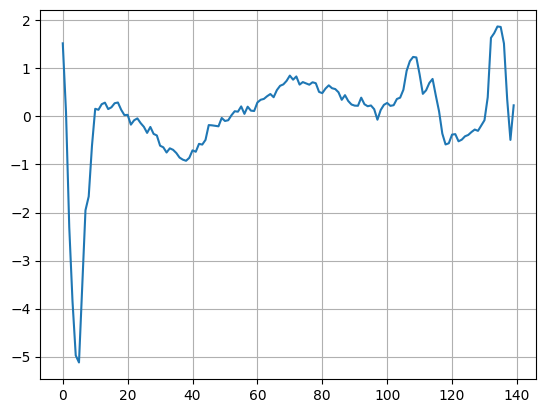

In [6]:
plt.plot(np.arange(140), train_data[0])
plt.grid()
plt.show()

Para melhorar o treinamento, podemos normalizar os dados no intervalo $[0,1]$.

In [7]:
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

print(train_data[0])

tf.Tensor(
[0.57030463 0.46561658 0.29058117 0.17791584 0.09538919 0.08467858
 0.20195104 0.3163002  0.33732033 0.41424882 0.47070596 0.4691905
 0.47767755 0.4800409  0.47027245 0.4729927  0.47917148 0.48027468
 0.4692887  0.46106863 0.46148038 0.4465829  0.45325327 0.45610094
 0.4489618  0.4432532  0.43402174 0.44307235 0.43250525 0.43014902
 0.41454658 0.4120653  0.4042028  0.41054544 0.4082913  0.40342993
 0.39648476 0.39332044 0.39158815 0.39603877 0.40746954 0.4053118
 0.4173488  0.41624558 0.42334118 0.44590637 0.4455184  0.44474098
 0.44404328 0.45673218 0.45217463 0.4532504  0.46082932 0.46695936
 0.46631944 0.4743283  0.4629709  0.4738895  0.46788898 0.4673448
 0.48026675 0.4843984  0.48574668 0.48985568 0.49317348 0.4883041
 0.49913937 0.5057092  0.5078241  0.51323026 0.5211993  0.5149918
 0.5199009  0.5074854  0.5113434  0.509294   0.5073482  0.5110538
 0.5096124  0.4963956  0.49456537 0.501491   0.5063671  0.50202936
 0.50071526 0.49582374 0.48436236 0.49142462 0.48253575 0

Gerando o gráfico novamente, podemos observar o efeito da normalização no intervalo de valores do sinal.

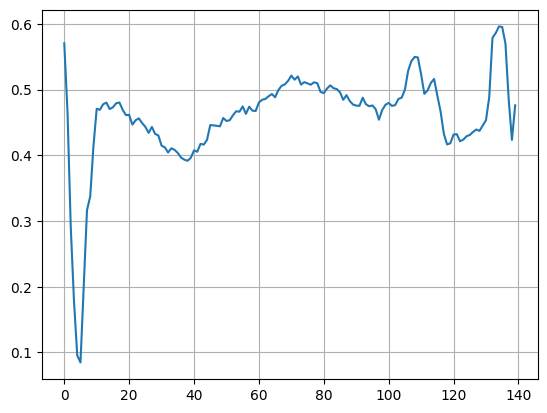

In [8]:
plt.plot(np.arange(140), train_data[0])
plt.grid()
plt.show()

Considerando que queremos utilizar um autoencoder, utilizaremos apenas os dados de entrada e ignoraremos (pelo menos durante o treinamento) os rótulos. Da mesma forma, os ECGs normais e anormais podem ser divididos, dado que o treinamento utilizará apenas os ECGs normais.

In [9]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

Abaixo podemos ver exemplos de ECGs normais e anormais.

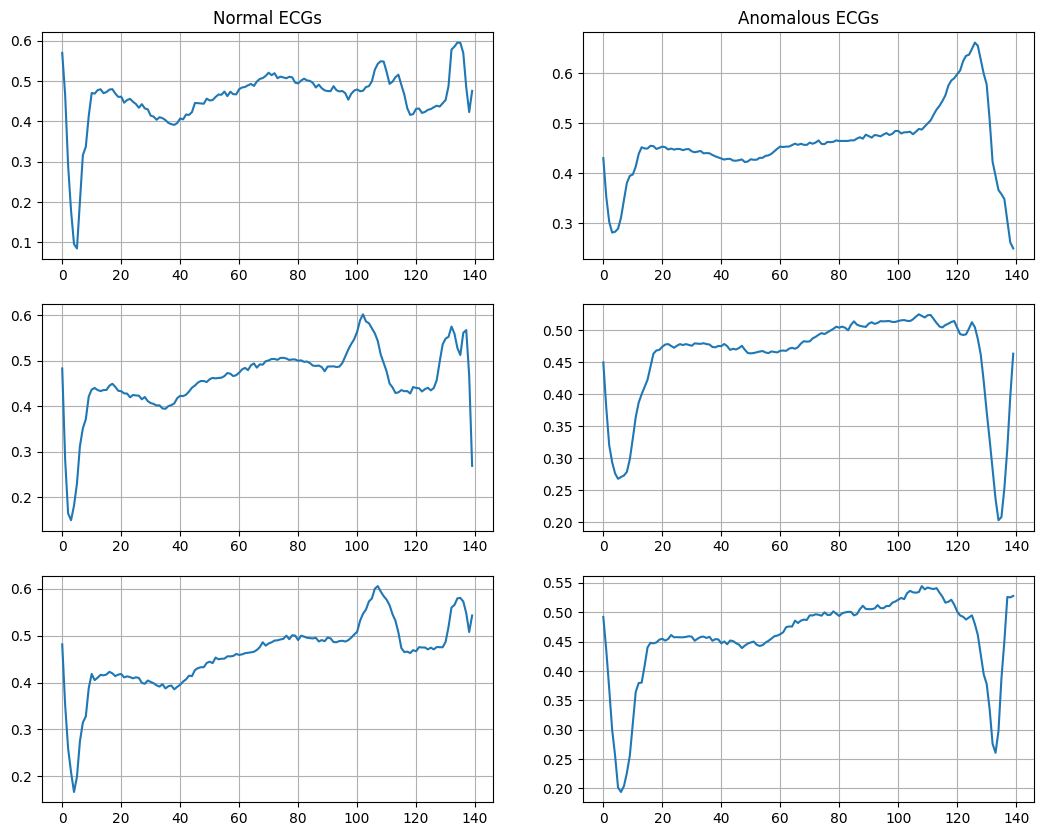

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(12.8, 10))

axs[0,0].set_title('Normal ECGs')
axs[0,0].grid()
axs[0,0].plot(np.arange(140), normal_train_data[0])
axs[1,0].grid()
axs[1,0].plot(np.arange(140), normal_train_data[1])
axs[2,0].grid()
axs[2,0].plot(np.arange(140), normal_train_data[2])

axs[0,1].set_title('Anomalous ECGs')
axs[0,1].grid()
axs[0,1].plot(np.arange(140), anomalous_train_data[0])
axs[1,1].grid()
axs[1,1].plot(np.arange(140), anomalous_train_data[1])
axs[2,1].grid()
axs[2,1].plot(np.arange(140), anomalous_train_data[2])

plt.show()

#Eixo X -> São as medições ao longo do tempo (140 medições)
#Eixo Y -> É o sinal elétrico do EletroCardiograma normalizado (ajustado no valor de 0 a 1)

Nosso próximo passo é criar o autoencoder. Novamente, utilizaremos o modelo sequencial para definir a arquitetura da nossa rede. No treinamento, utilizaremos um otimizador adam junto da função de erro MAE.

In [11]:
'''
Esse trecho é justamente onde o autoencoder é construído.
No seu notebook, cada ECG possui 140 valores de entrada, e a rede tenta comprimir esses 140 valores
em uma representação menor e depois reconstruir os 140 valores originais.
'''

autoencoder = Sequential() #Cria uma rede neural sequencial. Isto significa que as camadas são executadas uma após a outra.

#--------------------ENCODER----------------------------------
autoencoder.add(Dense(32, activation='relu')) #Dense significa uma camada totalmente conectada.
#32 significa a quantidade de neurônios da camada

autoencoder.add(Dense(16, activation='relu'))
autoencoder.add(Dense(8, activation='relu')) #Esta é a camada mais comprimida dos dados, em apenas 8 neurônios
#devem ser representadas as informações dos 140 valores de entrada. Esta é a chamada representação latente.

#--------------------DECODER----------------------------------
autoencoder.add(Dense(16, activation='relu'))
autoencoder.add(Dense(32, activation='relu'))
autoencoder.add(Dense(140, activation='sigmoid'))

autoencoder.compile(optimizer='adam', loss='mae')


Agora podemos iniciar o treinamento. Lembre-se que, por se tratar de um autoencoder, os dados de entrada são utilizados também como rótulos de modo que a rede consiga aprender a reconstruir os dados a partir da representação latente.

In [12]:
history = autoencoder.fit(
          normal_train_data, #entrada
          normal_train_data, #saída esperada, visto que a saída é uma reconstrução da entrada
          epochs=50, #50 CICLOS
          batch_size=128, #são usadas 128 amostras por vez para calcular o gradiente e atualizar os pesos
          validation_data=(test_data, test_data), #entrada de validação, e saída esperada.
          shuffle=True) #antes de cada época, embaralha a ordem das aostras para evitar que o modelo aprenda padrões indesejados.

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 0.0527 - val_loss: 0.0468
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0386 - val_loss: 0.0403
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0294 - val_loss: 0.0374
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0250 - val_loss: 0.0356
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0224 - val_loss: 0.0339
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0208 - val_loss: 0.0338
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0204 - val_loss: 0.0339
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0203 - val_loss: 0.0333
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0202 - val_loss: 0.0333
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0201 - val_loss: 0.0331
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0199 - val_loss: 0.0329
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0198 - val_

Logo após, podemos analisar a curva de aprendizado. Como pode ser observado, o erro cai rapidamente, dado que o problema (ao menos para estes dados) é razoavelmente simples.

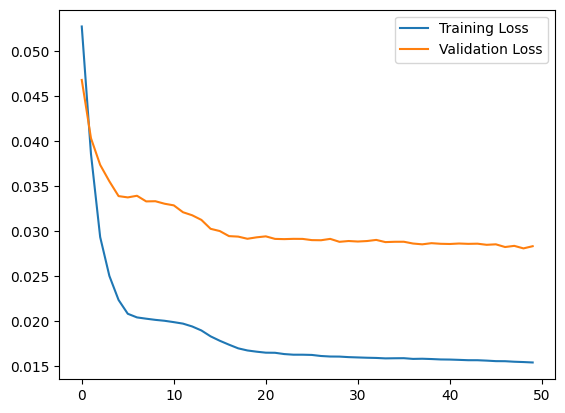

In [13]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

Treinado o modelo, nosso objetivo agora é detectar as anomalias. Lembre que nossa hipótese é que, ao treinar o modelo apenas com ECGs normais, o erro de reconstrução de ECGs anormais tende a ser grande. Podemos verificar se nossa hipótese comparando algumas amostras com as saídas correspondentes da rede. Como pode ser observado abaixo, ECGs anormais possuem um erro muito maior que o s ECGs normais.

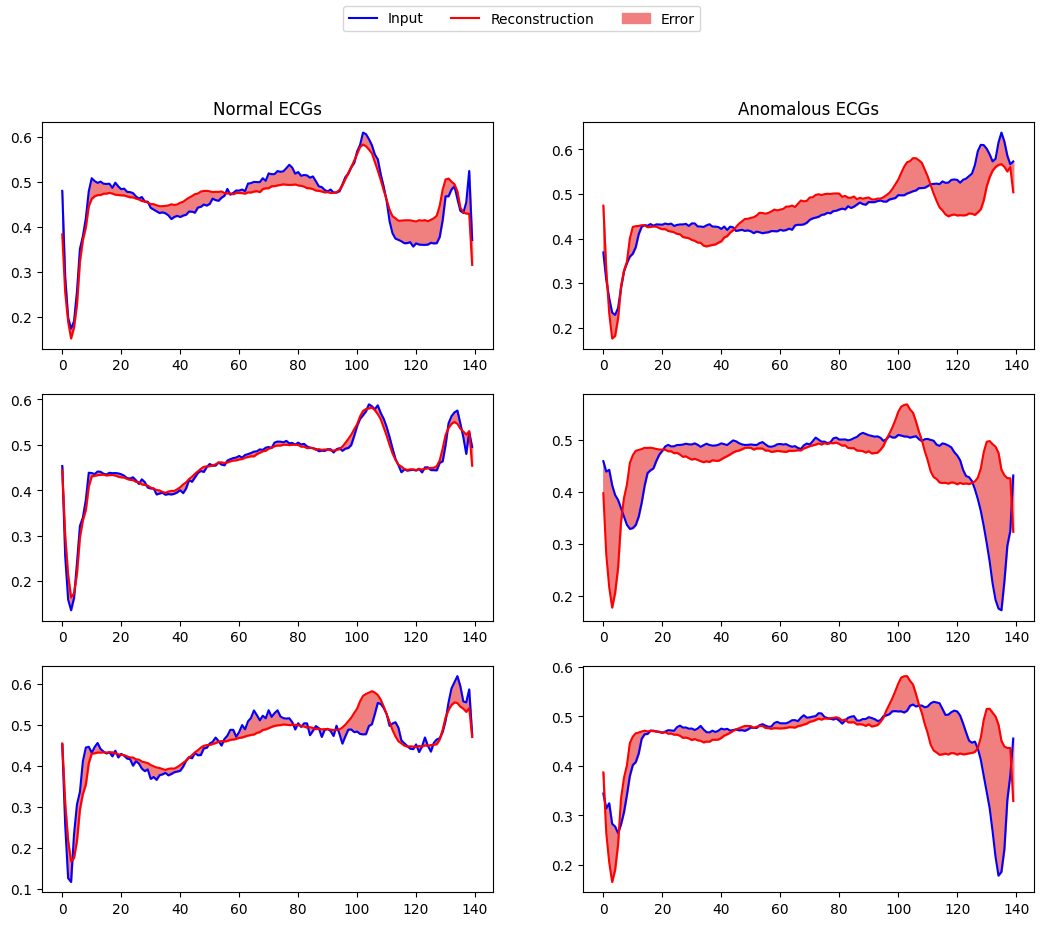

In [14]:
def sub_plot_axs(x, y, data, decoded_data, id):
  axs[x,y].plot(data[id],'b')
  axs[x,y].plot(decoded_data[id],'r')
  axs[x,y].fill_between(np.arange(140), decoded_data[id], data[id], color='lightcoral')


decoded_imgs_normal = autoencoder(normal_test_data).numpy()
decoded_imgs_anomalous = autoencoder(anomalous_test_data).numpy()

fig, axs = plt.subplots(3, 2, figsize=(12.8, 10))

axs[0,0].set_title('Normal ECGs')
sub_plot_axs(0,0,normal_test_data,decoded_imgs_normal,0)
sub_plot_axs(1,0,normal_test_data,decoded_imgs_normal,1)
sub_plot_axs(2,0,normal_test_data,decoded_imgs_normal,2)

axs[0,1].set_title('Anomalous ECGs')
sub_plot_axs(0,1,anomalous_test_data,decoded_imgs_anomalous,0)
sub_plot_axs(1,1,anomalous_test_data,decoded_imgs_anomalous,1)
sub_plot_axs(2,1,anomalous_test_data,decoded_imgs_anomalous,2)

fig.legend(labels=["Input", "Reconstruction", "Error"], loc='upper center', ncol=3)
plt.show()

De modo a entender melhor a diferença do erro de reconstrução de ECGs normais e anormais, podemos gerar um histograma destes erros.

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


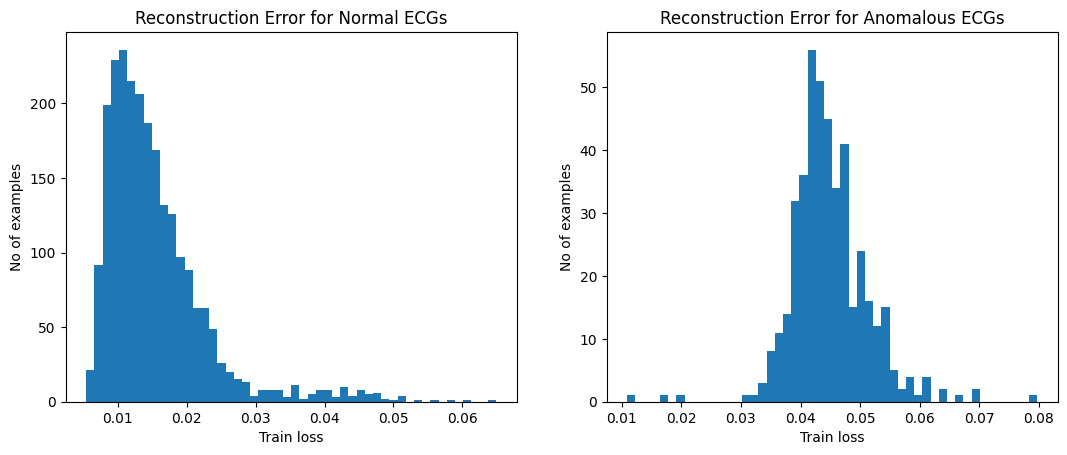

In [15]:
train_loss = tf.keras.losses.mae(autoencoder.predict(normal_train_data), normal_train_data)
test_loss = tf.keras.losses.mae(autoencoder.predict(anomalous_test_data), anomalous_test_data)

fig, axs = plt.subplots(1, 2, figsize=(12.8, 4.8))

axs[0].set_title('Reconstruction Error for Normal ECGs')
axs[0].hist(train_loss, bins=50)
axs[0].set(xlabel='Train loss', ylabel='No of examples')

axs[1].set_title('Reconstruction Error for Anomalous ECGs')
axs[1].hist(test_loss, bins=50)
axs[1].set(xlabel='Train loss', ylabel='No of examples')

plt.show()

Como pode ser observado, o erro de construção médio dos ECGs normais fica próximo de 0.01 enquanto o dos ECGs anormais fica em torno de 0.04. Desta forma, criaremos um *threshold* no erro de reconstrução para diferenciar ECGs normais de anormais. Em particular, vamos assumir que este *threshold* é igual ao erro médio mais três desvios padrão.

In [16]:
threshold = np.mean(train_loss) + 3 * np.std(train_loss)
print("Threshold: ", threshold)

Threshold:  0.037908252


Finalmente, podemos avaliar o desempenho do nosso modelo medindo algumas métricas, como abaixo.

In [17]:
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold)

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, preds)))
  print("Precision = {}".format(precision_score(labels, preds)))
  print("Recall = {}".format(recall_score(labels, preds)))

preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.949
Precision = 0.9410745233968805
Recall = 0.9696428571428571


## Exercícios

### Integrantes do grupo: Barbara, Eduardo, Marcelo

### Exercício 1

Reduza a complexidade do autoencoder sem afetar negativamente os resultados obtidos. Ao final, faça uma comparação dos resultados obtidos com os orginais.

In [18]:
#TODO sua resposta aqui

### Exercício 2

Teste o que acontece se o autoencoder for treinado com os sinais anômalos ao invés dos normais. O desempenho melhora? Existe algum efeito negativo desta abordagem alternativa?

In [19]:
#TODO sua resposta aqui

### Exercício 3

Repita o pipeline acima para um conjunto de dados sintéticos. A função abaixo exemplifica uma série sintética linear com ruído gaussiano. Considere séries um pouco mais interessantes e complexas. Não esqueça de gerar séries de padrões diferentes, dado que o autoencoder deve detectar anomalias.

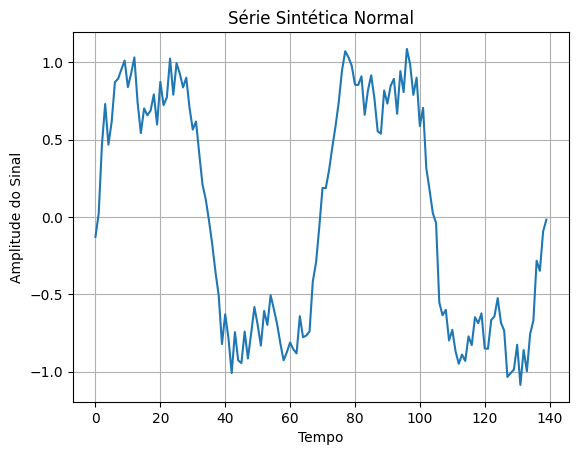

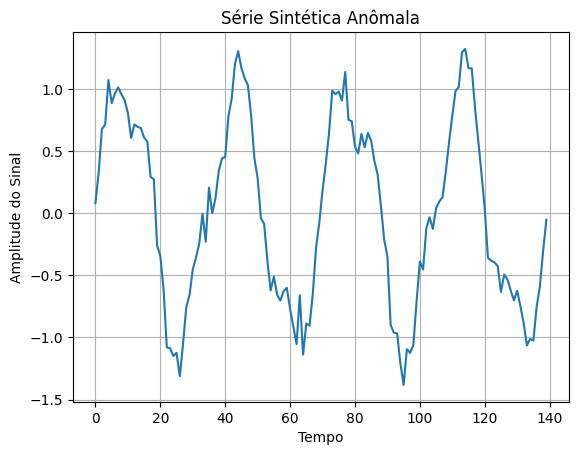

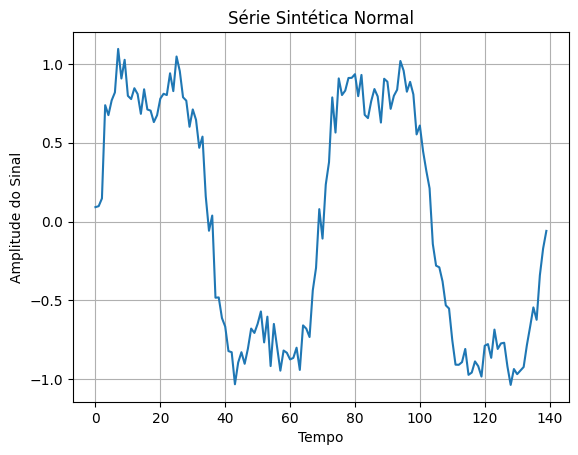

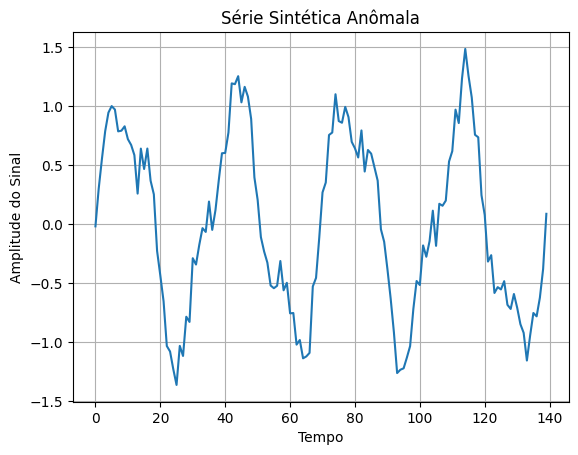

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 291ms/step - loss: 0.2606 - val_loss: 0.2503
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2405 - val_loss: 0.2196
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2018 - val_loss: 0.1710
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1561 - val_loss: 0.1348
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1236 - val_loss: 0.1039
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0912 - val_loss: 0.0733
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0656 - val_loss: 0.0543
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0491 - val_loss: 0.0431
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0402 - val_loss: 0.0369
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0353 - val_loss: 0.0332
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0325 - val_loss: 0.0316
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0313 - val_loss: 0.0310


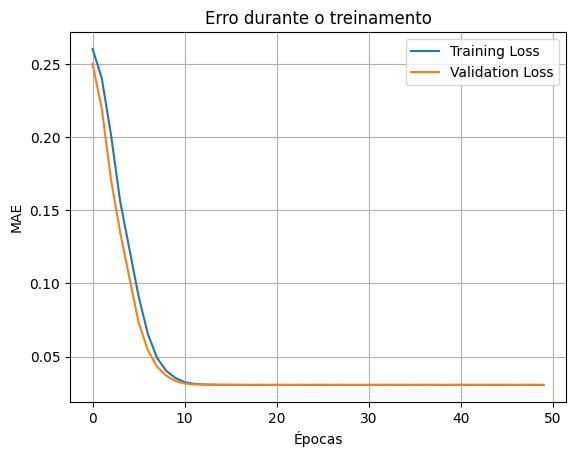

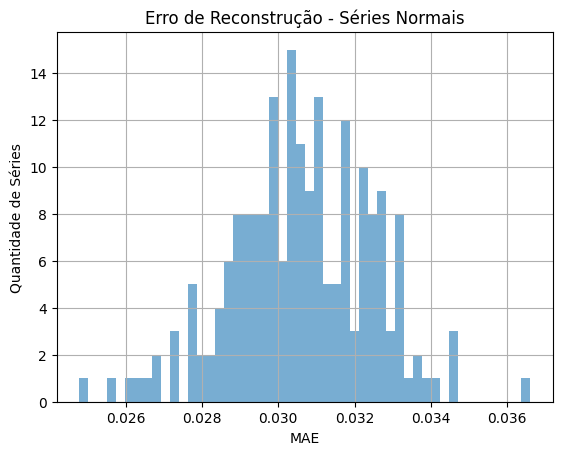

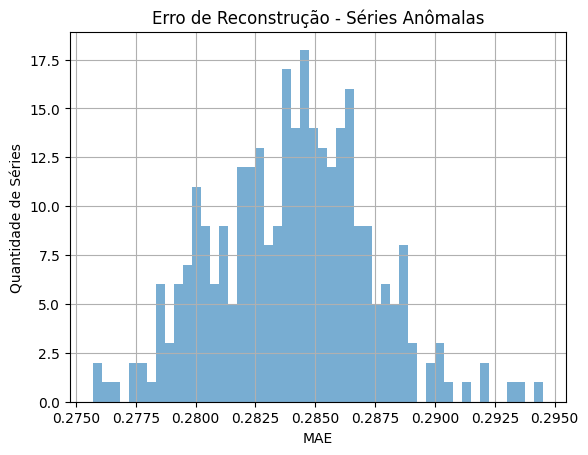

Threshold: 0.03638844311126244
Accuracy = 0.998
Precision = 1.0
Recall = 0.995


In [34]:
tam = 140


# ------------------- SÉRIE NORMAL -------------------

def gerar_serie_normal(ruido=0.1):

    x = np.linspace(0, 4 * np.pi, tam)

    serie = (
        np.sin(x)
        + 0.3 * np.sin(3 * x)
        + np.random.normal(0, ruido, tam)
    )

    return serie


# Plot da série normal
plt.plot(np.arange(tam), gerar_serie_normal())
plt.title("Série Sintética Normal")
plt.xlabel("Tempo")
plt.ylabel("Amplitude do Sinal")
plt.grid()
plt.show()


# ------------------- SÉRIE ANÔMALA -------------------

def gerar_serie_anomala(ruido=0.1):

    x = np.linspace(0, 4 * np.pi, tam)

    serie = (
        np.sin(2 * x)
        + 0.3 * np.sin(5 * x)
        + np.random.normal(0, ruido, tam)
    )

    return serie


# Plot da série anômala
plt.plot(np.arange(tam), gerar_serie_anomala())
plt.title("Série Sintética Anômala")
plt.xlabel("Tempo")
plt.ylabel("Amplitude do Sinal")
plt.grid()
plt.show()


# ------------------- GERANDO O DATASET -------------------

# Gravando 1000 séries normais
normal_data = np.array([
    gerar_serie_normal()
    for _ in range(1000)
])

# Gravando 300 séries anômalas
anomalous_data = np.array([
    gerar_serie_anomala()
    for _ in range(300)
])


# ------------------- TREINO E TESTE -------------------

# 80% treino e 20% teste das séries normais
normal_train_data, normal_test_data = train_test_split(
    normal_data,
    test_size=0.2,
    random_state=42
)


# ------------------- NORMALIZAÇÃO -------------------

# Pegamos mínimo e máximo APENAS dos dados de treino
min_val = np.min(normal_train_data)
max_val = np.max(normal_train_data)

# Normalizando entre 0 e 1
normal_train_data = (
    normal_train_data - min_val
) / (max_val - min_val)

normal_test_data = (
    normal_test_data - min_val
) / (max_val - min_val)

anomalous_data = (
    anomalous_data - min_val
) / (max_val - min_val)


# ------------------- AUTOENCODER -------------------

autoencoder = Sequential()

# Encoder
autoencoder.add(Dense(32, activation='relu'))
autoencoder.add(Dense(16, activation='relu'))
autoencoder.add(Dense(8, activation='relu'))

# Decoder
autoencoder.add(Dense(16, activation='relu'))
autoencoder.add(Dense(32, activation='relu'))

# A sigmoid produz saídas aproximadamente entre 0 e 1
autoencoder.add(Dense(140, activation='sigmoid'))

autoencoder.compile(
    optimizer='adam',
    loss='mae'
)


# ------------------- TREINAMENTO -------------------

# O modelo aprende SOMENTE o padrão normal
history = autoencoder.fit(
    normal_train_data,
    normal_train_data,
    epochs=50,
    batch_size=128,
    validation_data=(normal_test_data, normal_test_data),
    shuffle=True
)


# ------------------- LOSS E VALIDATION LOSS -------------------

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Erro durante o treinamento")
plt.xlabel("Épocas")
plt.ylabel("MAE")
plt.legend()
plt.grid()
plt.show()


# ------------------- RECONSTRUÇÕES -------------------

# Séries normais reconstruídas
recon_normal = autoencoder(normal_test_data).numpy()

# Séries anômalas reconstruídas
recon_anom = autoencoder(anomalous_data).numpy()


# ------------------- ERRO DE RECONSTRUÇÃO -------------------

# Erro das séries normais de TESTE
normal_loss = tf.keras.losses.mae(
    recon_normal,
    normal_test_data
)

# Erro das séries anômalas
anomalous_loss = tf.keras.losses.mae(
    recon_anom,
    anomalous_data
)


# IMPORTANTE:
# Também precisamos calcular o erro das séries normais de TREINO
recon_train = autoencoder(normal_train_data).numpy()

normal_train_loss = tf.keras.losses.mae(
    recon_train,
    normal_train_data
)


# ------------------- HISTOGRAMA DOS ERROS NORMAIS -------------------

plt.hist(
    normal_loss,
    bins=50,
    alpha=0.6
)

plt.title("Erro de Reconstrução - Séries Normais")
plt.xlabel("MAE")
plt.ylabel("Quantidade de Séries")
plt.grid()
plt.show()


# ------------------- HISTOGRAMA DOS ERROS ANÔMALOS -------------------

plt.hist(
    anomalous_loss,
    bins=50,
    alpha=0.6
)

plt.title("Erro de Reconstrução - Séries Anômalas")
plt.xlabel("MAE")
plt.ylabel("Quantidade de Séries")
plt.grid()
plt.show()


# ------------------- THRESHOLD -------------------

# Limite utilizado para separar normal de anômalo
threshold = (
    np.mean(normal_train_loss)
    + 3 * np.std(normal_train_loss)
)

print("Threshold:", threshold)


# ------------------- CLASSIFICAÇÃO -------------------

def predict(model, data, threshold):

    reconstructions = model(data)

    loss = tf.keras.losses.mae(
        reconstructions,
        data
    )

    # True = normal
    # False = anômalo
    return tf.math.less(loss, threshold)


# ------------------- LABELS -------------------

# 1 = normal
labels_normal = np.ones(
    len(normal_test_data)
)

# 0 = anômalo
labels_anomalous = np.zeros(
    len(anomalous_data)
)


# ------------------- JUNTANDO OS DADOS DE TESTE -------------------

test_data = np.concatenate([
    normal_test_data,
    anomalous_data
])

test_labels = np.concatenate([
    labels_normal,
    labels_anomalous
])


# ------------------- PREVISÕES -------------------

preds = predict(
    autoencoder,
    test_data,
    threshold
)


# ------------------- MÉTRICAS -------------------

print(
    "Accuracy =",
    accuracy_score(test_labels, preds)
)

print(
    "Precision =",
    precision_score(test_labels, preds)
)

print(
    "Recall =",
    recall_score(test_labels, preds)
)

NameError: name 'normal_train_loss' is not defined

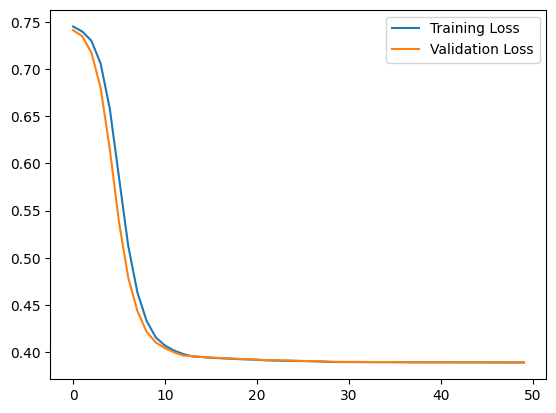

In [ ]:
#TODO sua resposta aqui

## Referências



* https://www.tensorflow.org/tutorials/generative/autoencoder#third_example_anomaly_detection